In [22]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto

def run_evt_on_folder(
    folder_path, 
    latency_col="end_to_end_latency_seconds",
    percentile_threshold=90,
    output_dir="evt_output"
):
    """
    Runs EVT analysis on all CSV files in the given folder.

    Parameters:
    - folder_path: str, path to folder containing CSV files
    - latency_col: str, column name for latency values (in seconds)
    - percentile_threshold: int, threshold percentile for EVT tail fitting
    - output_dir: str, directory to save plots and reports
    """

    # Step 1: Load all CSVs
    csv_paths = glob.glob(os.path.join(folder_path, "*.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No CSV files found in {folder_path}")
    
    print(f"[INFO] Found {len(csv_paths)} CSV files.")

    all_data = []
    for path in csv_paths:
        try:
            df = pd.read_csv(path)
            if latency_col not in df.columns:
                print(f"[WARN] '{latency_col}' not in {path}, skipping.")
                continue
            all_data.extend(df[latency_col].dropna().values)
        except Exception as e:
            print(f"[ERROR] Failed to load {path}: {e}")

    if not all_data:
        raise ValueError(f"No valid latency data found in column '{latency_col}'.")

    latencies = np.array(all_data)
    print(f"[INFO] Loaded {len(latencies)} latency samples.")

    # Step 2: EVT threshold
    u = np.percentile(latencies, percentile_threshold)
    exceedances = latencies[latencies > u] - u
    proportion_below = np.mean(latencies <= u)
    print(f"[INFO] Threshold u = {u:.6f} s | proportion <= u: {proportion_below:.4f} | exceedances: {len(exceedances)}")

    # Step 3: Fit GPD
    xi, loc, beta = genpareto.fit(exceedances, floc=0)
    print(f"[INFO] Fitted GPD params (exceedances): xi={xi:.5f}, beta={beta:.6f}")

    # Step 4: Estimate high percentiles
    def estimate_quantile(p):
        return u + (beta / xi) * (( (1 - p) / (1 - proportion_below) ) ** (-xi) - 1) if xi != 0 else u - beta * np.log((1 - p) / (1 - proportion_below))

    p90 = estimate_quantile(0.90) * 1000
    p95 = estimate_quantile(0.95) * 1000
    p99 = estimate_quantile(0.99) * 1000
    p999 = estimate_quantile(0.999) * 1000

    print(f"Estimated p90 latency: {p90:.2f} ms")
    print(f"Estimated p95 latency: {p95:.2f} ms")
    print(f"Estimated p99 latency: {p99:.2f} ms")
    print(f"Estimated p99.9 latency: {p999:.2f} ms")

    # Step 5: Probabilities
    def prob_exceed(t):
        return ((1 - proportion_below) * (1 + xi * (t - u) / beta) ** (-1/xi)) if xi != 0 else (1 - proportion_below) * np.exp(-(t - u) / beta)

    p500 = prob_exceed(0.5) * 100
    p1000 = prob_exceed(1.0) * 100
    print(f"P(latency > 500 ms) ≈ {p500:.4f}%")
    print(f"P(latency > 1000 ms) ≈ {p1000:.4f}%")

    # Step 6: Plots
    os.makedirs(output_dir, exist_ok=True)
    plt.figure(figsize=(8, 5))
    plt.hist(exceedances, bins=50, density=True, alpha=0.6, label="Exceedances")
    x_vals = np.linspace(0, exceedances.max(), 1000)
    plt.plot(x_vals, genpareto.pdf(x_vals, xi, loc=0, scale=beta), 'r-', lw=2, label="Fitted GPD")
    plt.xlabel("Exceedance over threshold (s)")
    plt.ylabel("Density")
    plt.legend()
    plt.title("GPD Fit to Latency Tail")
    plt.savefig(os.path.join(output_dir, "gpd_fit.png"))
    plt.close()

    print(f"[INFO] Wrote plots to {output_dir}")

    return {
        "xi": xi,
        "beta": beta,
        "threshold_s": u,
        "p90_ms": p90,
        "p95_ms": p95,
        "p99_ms": p99,
        "p999_ms": p999,
        "prob_gt_500ms_percent": p500,
        "prob_gt_1000ms_percent": p1000
    }


In [24]:
results = run_evt_on_folder(
    folder_path="20250810_211308/consumer/consumer-sts-0_consumer-result/2025-08-10/20-25-02/",
    latency_col="end_to_end_latency_seconds",
    percentile_threshold=90
)
results


[INFO] Found 575 CSV files.
[INFO] Loaded 57500 latency samples.
[INFO] Threshold u = 0.016491 s | proportion <= u: 0.9000 | exceedances: 5749
[INFO] Fitted GPD params (exceedances): xi=0.14839, beta=0.081524
Estimated p90 latency: 16.48 ms
Estimated p95 latency: 75.99 ms
Estimated p99 latency: 240.24 ms
Estimated p99.9 latency: 555.15 ms
P(latency > 500 ms) ≈ 0.1420%
P(latency > 1000 ms) ≈ 0.0099%
[INFO] Wrote plots to evt_output


{'xi': 0.1483872599632578,
 'beta': 0.08152373193202742,
 'threshold_s': 0.0164909362792968,
 'p90_ms': 16.476757188917652,
 'p95_ms': 75.99145450018743,
 'p99_ms': 240.2419931477404,
 'p999_ms': 555.1472246822282,
 'prob_gt_500ms_percent': 0.14198161903642925,
 'prob_gt_1000ms_percent': 0.009926109319071352}

In [28]:
import os, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto, pareto, lognorm, weibull_min, expon

def diagnose_latency_tail(
    folder_path,
    latency_col="end_to_end_latency_seconds",
    percentile_threshold=90,
    outdir="evt_output"
):
    # ---------- Load data ----------
    csvs = glob.glob(os.path.join(folder_path, "*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSV files in {folder_path}")
    vals = []
    for p in csvs:
        try:
            df = pd.read_csv(p)
            if latency_col in df.columns:
                vals.append(pd.to_numeric(df[latency_col], errors="coerce"))
        except Exception as e:
            print(f"[WARN] {p}: {e}")
    x = pd.concat(vals, ignore_index=True).dropna().values
    x = x[x >= 0]
    print(f"[INFO] Loaded {len(x)} samples.")

    # ---------- Threshold & exceedances (POT) ----------
    u = np.percentile(x, percentile_threshold)
    tail = x[x > u]
    y = tail - u  # exceedances
    if len(y) < 50:
        raise ValueError(f"Too few exceedances above threshold: {len(y)}. Lower the threshold or gather more data.")
    p_u = (x <= u).mean()
    print(f"[INFO] Threshold u={u:.6f}s  proportion<=u={p_u:.3f}  exceedances={len(y)}")

    # ---------- Fit GPD on exceedances ----------
    xi, loc, beta = genpareto.fit(y, floc=0)
    print(f"[INFO] GPD fit: xi={xi:.5f}, beta={beta:.6f}")
    tail_type = "Heavy-tailed (Fréchet)" if xi>0 else ("Exponential/Gumbel" if abs(xi)<1e-6 else "Bounded (Weibull)")
    print(f"[INFO] Tail classification from xi: {tail_type}")

    # ---------- Fit alternative tail models to y (exceedances) ----------
    # Pareto: support y >= m; fit with scipy.pareto (shape 'b', loc, scale)
    # We'll force loc=0 so support starts at 0; this is a heuristic for tail-only fitting
    b_par, loc_par, scale_par = pareto.fit(y, floc=0)  # y ~ Pareto(b, scale)
    # Lognormal
    s_logn, loc_logn, scale_logn = lognorm.fit(y, floc=0)
    # Weibull (minimum)
    c_weib, loc_weib, scale_weib = weibull_min.fit(y, floc=0)
    # Exponential
    loc_exp, scale_exp = 0.0, np.mean(y)  # MLE for expon with loc=0

    # ---------- Simple AIC comparison on exceedances ----------
    def loglik_gpd(y, xi, beta):
        if xi == 0:
            ll = -np.log(beta) - y/beta
            return ll.sum()
        base = 1 + xi*y/beta
        if np.any(base <= 0):
            return -np.inf
        return -len(y)*np.log(beta) - (1/xi + 1)*np.log(base).sum()

    def loglik_pdf(y, pdf):
        z = pdf(y) + 1e-300
        return np.log(z).sum()

    aic = {}
    aic['GPD']      = 2*2 - 2*loglik_gpd(y, xi, beta)                 # 2 params: xi, beta
    aic['Pareto']   = 2*2 - 2*loglik_pdf(y, lambda t: pareto.pdf(t, b_par, loc=0, scale=scale_par))
    aic['Lognormal']= 2*2 - 2*loglik_pdf(y, lambda t: lognorm.pdf(t, s_logn, loc=0, scale=scale_logn))
    aic['Weibull']  = 2*2 - 2*loglik_pdf(y, lambda t: weibull_min.pdf(t, c_weib, loc=0, scale=scale_weib))
    aic['Exponential']= 2*1 - 2*loglik_pdf(y, lambda t: expon.pdf(t, loc=0, scale=scale_exp))  # 1 param

    print("[INFO] Tail AIC (lower is better):", {k: round(v,2) for k,v in aic.items()})
    best = min(aic.items(), key=lambda kv: kv[1])[0]
    print(f"[INFO] Best tail by AIC on exceedances: {best}")

    os.makedirs(outdir, exist_ok=True)

    # ---------- Plot 1: Histogram of exceedances + fitted PDFs ----------
    plt.figure(figsize=(8,5))
    bins = max(30, int(np.sqrt(len(y))))
    plt.hist(y, bins=bins, density=True, alpha=0.5, label="Exceedances (y=x-u)")
    grid = np.linspace(0, np.percentile(y, 99.5), 500)
    plt.plot(grid, genpareto.pdf(grid, xi, loc=0, scale=beta), lw=2, label="GPD fit")
    plt.plot(grid, pareto.pdf(grid, b_par, loc=0, scale=scale_par), lw=1.5, label="Pareto fit")
    plt.plot(grid, lognorm.pdf(grid, s_logn, loc=0, scale=scale_logn), lw=1.5, label="Lognormal fit")
    plt.plot(grid, weibull_min.pdf(grid, c_weib, loc=0, scale=scale_weib), lw=1.5, label="Weibull fit")
    plt.plot(grid, expon.pdf(grid, loc=0, scale=scale_exp), lw=1.5, label="Exponential fit")
    plt.xlabel("Exceedance y = x - u (seconds)")
    plt.ylabel("Density")
    plt.title("Tail exceedances: fitted PDFs")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "tail_pdfs.png"))
    plt.close()

    # ---------- Plot 2: Tail CCDF (survival) on log–log ----------
    ys = np.sort(y)
    emp_sf = 1.0 - (np.arange(1, len(ys)+1) / (len(ys)+1.0))
    def gpd_sf(t): 
        base = np.maximum(1 + xi*t/beta, 1e-12)
        return np.exp(-t/beta) if abs(xi)<1e-8 else base**(-1/xi)
    def pareto_sf(t):
        return pareto.sf(t, b_par, loc=0, scale=scale_par)
    def lognorm_sf(t):
        return lognorm.sf(t, s_logn, loc=0, scale=scale_logn)
    def weibull_sf(t):
        return weibull_min.sf(t, c_weib, loc=0, scale=scale_weib)
    def exp_sf(t):
        return np.exp(-t/scale_exp)

    grid2 = np.linspace(ys.min(), np.percentile(ys, 99.5), 400)
    plt.figure(figsize=(7,5))
    plt.loglog(ys + 1e-12, emp_sf, 'o', ms=3, alpha=0.6, label="Empirical tail CCDF")
    plt.loglog(grid2+1e-12, [gpd_sf(t) for t in grid2], label="GPD")
    plt.loglog(grid2+1e-12, pareto_sf(grid2), label="Pareto")
    plt.loglog(grid2+1e-12, lognorm_sf(grid2), label="Lognormal")
    plt.loglog(grid2+1e-12, weibull_sf(grid2), label="Weibull")
    plt.loglog(grid2+1e-12, exp_sf(grid2), label="Exponential")
    plt.xlabel("Exceedance y (s)  [log]")
    plt.ylabel("P(Y>y)  [log]")
    plt.title("Tail CCDF (log–log): straight line ≈ Pareto-like")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "tail_ccdf_loglog.png"))
    plt.close()

    # ---------- Plot 3: GPD QQ-plot ----------
    probs = (np.arange(1, len(ys)+1) - 0.5) / len(ys)
    theo = genpareto.ppf(probs, xi, loc=0, scale=beta)
    plt.figure(figsize=(6,6))
    plt.plot(theo, ys, 'o', ms=3, alpha=0.6)
    mmin, mmax = min(theo.min(), ys.min()), max(theo.max(), ys.max())
    plt.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1)
    plt.xlabel("Theoretical GPD quantiles")
    plt.ylabel("Empirical exceedances")
    plt.title("GPD QQ-plot (tail)")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "gpd_qqplot.png"))
    plt.close()

    # ---------- Quick interpretive hints ----------
    print("\n[READ ME]")
    print("- If the CCDF log–log plot is ~a straight line in the tail, it's Pareto-like (heavy).")
    print("- If CCDF is straight on a semi-log (not shown), it's exponential-like.")
    print("- Curved tail on log–log often indicates lognormal/Weibull.")
    print(f"- Your xi={xi:.3f} -> {tail_type}. Best AIC fit here: {best}.")
    print(f"[DONE] Plots saved to: {outdir}")

# Example:
diagnose_latency_tail("20250810_211308/consumer/consumer-sts-0_consumer-result/2025-08-10/20-25-02/", latency_col="end_to_end_latency_seconds", percentile_threshold=90)


[INFO] Loaded 57500 samples.
[INFO] Threshold u=0.016491s  proportion<=u=0.900  exceedances=5749
[INFO] GPD fit: xi=0.14839, beta=0.081524
[INFO] Tail classification from xi: Heavy-tailed (Fréchet)
[INFO] Tail AIC (lower is better): {'GPD': -15615.15, 'Pareto': -8095.96, 'Lognormal': -17238.38, 'Weibull': -19536.1, 'Exponential': -15540.86}
[INFO] Best tail by AIC on exceedances: Weibull


/Users/soheila/.pyenv/versions/3.8.18/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:2267: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))



[READ ME]
- If the CCDF log–log plot is ~a straight line in the tail, it's Pareto-like (heavy).
- If CCDF is straight on a semi-log (not shown), it's exponential-like.
- Curved tail on log–log often indicates lognormal/Weibull.
- Your xi=0.148 -> Heavy-tailed (Fréchet). Best AIC fit here: Weibull.
[DONE] Plots saved to: evt_output


In [27]:
%pip install -q numpy pandas scipy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [29]:
import os, glob, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Tuple

import scipy.stats as st

plt.rcParams["figure.figsize"] = (7,5)

# -----------------------
# Generic helpers
# -----------------------
def ecdf(x: np.ndarray):
    x = np.sort(x)
    y = np.arange(1, len(x)+1)/len(x)
    return x, y

def aic_from_loglik(loglik: float, k_params: int) -> float:
    return 2*k_params - 2*loglik

def loglik_from_pdf(x: np.ndarray, pdf_values: np.ndarray) -> float:
    pdf_values = np.maximum(pdf_values, 1e-300)
    return float(np.log(pdf_values).sum())

def ks_test(x: np.ndarray, dist, params: Tuple) -> Tuple[float, float]:
    """Kolmogorov–Smirnov test for continuous distributions."""
    # st.kstest expects the dist name or a callable CDF with params
    return st.kstest(x, dist.cdf, args=params)

def print_table(rows, headers):
    widths = [max(len(h), max(len(str(r[i])) for r in rows)) for i,h in enumerate(headers)]
    print(" | ".join(h.ljust(widths[i]) for i,h in enumerate(headers)))
    print("-+-".join("-"*w for w in widths))
    for r in rows:
        print(" | ".join(str(r[i]).ljust(widths[i]) for i in range(len(headers))))


In [30]:
# ==== CONFIG ====
FOLDER = "20250810_211308/consumer/consumer-sts-0_consumer-result/2025-08-10/20-25-02/"  
LAT_COL = "end_to_end_latency_seconds"  # change if different
ASSUME_MS = False                # set True if column is in milliseconds
OUTDIR = "evt_output"            # where to save plots
os.makedirs(OUTDIR, exist_ok=True)

# ---- Load ----
csvs = sorted(glob.glob(os.path.join(FOLDER, "*.csv")))
if not csvs:
    raise FileNotFoundError(f"No CSV files found in {FOLDER}")

series = []
for p in csvs:
    try:
        df = pd.read_csv(p)
        if LAT_COL not in df.columns:
            print(f"[WARN] {os.path.basename(p)} missing '{LAT_COL}', skipping.")
            continue
        s = pd.to_numeric(df[LAT_COL], errors="coerce").dropna()
        series.append(s)
    except Exception as e:
        print(f"[WARN] Failed {p}: {e}")

if not series:
    raise ValueError(f"No usable '{LAT_COL}' values found.")

x = pd.concat(series, ignore_index=True).to_numpy()
x = x[np.isfinite(x)]
x = x[x >= 0]

if ASSUME_MS:
    x = x / 1000.0  # convert to seconds

print(f"[INFO] Loaded {len(x)} samples. "
      f"Median={np.median(x)*1000:.2f} ms, Mean={x.mean()*1000:.2f} ms")


[INFO] Loaded 57500 samples. Median=11.43 ms, Mean=21.00 ms


dist    | params                    | AIC                 | KS_stat             | KS_p
--------+---------------------------+---------------------+---------------------+-----
lognorm | (0.755131, 0.0, 0.012463) | -373386.7389145244  | 0.26502398347103273 | 0.0 
weibull | (0.896635, 0.0, 0.019371) | -331242.20528922544 | 0.3330567755921561  | 0.0 
gamma   | (1.094944, 0.0, 0.019179) | -329559.5259739506  | 0.37768343447811703 | 0.0 
expon   | (0.0, 0.021)              | -329268.5605314722  | 0.3676745782480044  | 0.0 

[WHOLE] Best (AIC): lognorm with params (0.755131, 0.0, 0.012463)


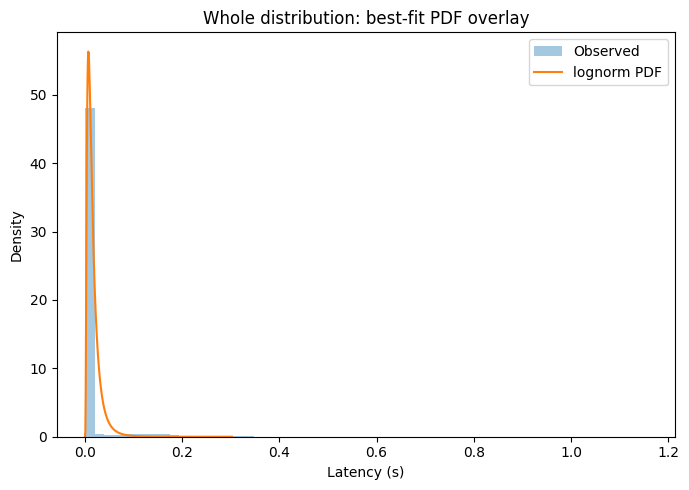

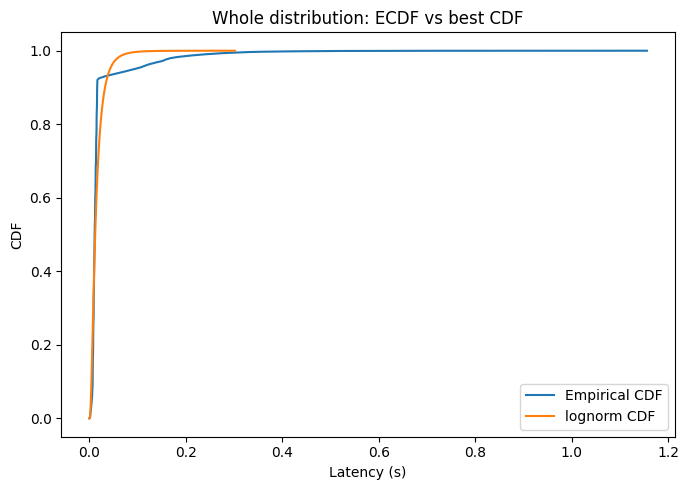

In [31]:
candidates = {
    "lognorm": st.lognorm,      # (s, loc, scale)
    "gamma":   st.gamma,        # (a, loc, scale)
    "weibull": st.weibull_min,  # (c, loc, scale)
    "expon":   st.expon,        # (loc, scale)
}

fit_rows = []
for name, dist in candidates.items():
    # force non-negative support with loc>=0 (let MLE choose exact loc)
    params = dist.fit(x, floc=0) if name != "expon" else dist.fit(x, floc=0)
    # Compute log-likelihood via PDF
    pdf = dist.pdf(x, *params)
    ll = loglik_from_pdf(x, pdf)
    k = len(params)
    aic = aic_from_loglik(ll, k)
    # KS
    ks_stat, ks_p = ks_test(x, dist, params)
    fit_rows.append([name, tuple(round(float(p), 6) for p in params), aic, ks_stat, ks_p])

fit_rows.sort(key=lambda r: r[2])  # lowest AIC first
print_table(fit_rows, ["dist", "params", "AIC", "KS_stat", "KS_p"])

best_name = fit_rows[0][0]
best_dist = candidates[best_name]
best_params = fit_rows[0][1]
print(f"\n[WHOLE] Best (AIC): {best_name} with params {best_params}")

# Plot histogram + best-fit PDF
grid = np.linspace(0, np.quantile(x, 0.995), 400)
plt.hist(x, bins=60, density=True, alpha=0.4, label="Observed")
plt.plot(grid, best_dist.pdf(grid, *candidates[best_name].fit(x, floc=0)), label=f"{best_name} PDF")
plt.xlabel("Latency (s)")
plt.ylabel("Density")
plt.title("Whole distribution: best-fit PDF overlay")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "whole_pdf.png"))
plt.show()

# ECDF vs best CDF
xs, ec = ecdf(x)
plt.plot(xs, ec, label="Empirical CDF")
plt.plot(grid, best_dist.cdf(grid, *candidates[best_name].fit(x, floc=0)), label=f"{best_name} CDF")
plt.xlabel("Latency (s)")
plt.ylabel("CDF")
plt.title("Whole distribution: ECDF vs best CDF")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "whole_cdf.png"))
plt.show()


In [32]:
# Choose threshold at the 90th percentile (adjust if needed)
PCT = 90
u = float(np.percentile(x, PCT))
tail = x[x > u]
y = tail - u   # exceedances
p_u = (x <= u).mean()

if len(y) < 50:
    raise ValueError(f"Only {len(y)} exceedances above u; choose a lower threshold.")

# Fit GPD to exceedances (loc=0)
xi, loc_gpd, beta = st.genpareto.fit(y, floc=0)
print(f"[EVT] u={u:.6f}s, exceedances={len(y)}, proportion<=u={p_u:.3f}")
print(f"[GPD] xi={xi:.5f}, beta={beta:.6f}")

tail_kind = "Heavy-tailed (Fréchet)" if xi>0 else ("Exponential/Gumbel" if abs(xi)<1e-8 else "Bounded (Weibull)")
print(f"[EVT] Tail classification: {tail_kind}")

# Functions for global quantiles/probabilities using POT model
def gpd_quantile_global(p: float, u: float, xi: float, beta: float, p_u: float) -> float:
    if p <= p_u:  # below threshold, use empirical quantile
        return float(np.quantile(x, p))
    q = (1 - p) / (1 - p_u)  # conditional tail prob
    if abs(xi) < 1e-10:
        yq = beta * np.log(1/q)
    else:
        yq = (beta/xi) * (q**(-xi) - 1)
    return u + yq

def prob_exceed_global(s: float, u: float, xi: float, beta: float, p_u: float) -> float:
    if s <= u:
        return float((x > s).mean())
    y = s - u
    if abs(xi) < 1e-10:
        tail_cond = math.exp(-y/beta)
    else:
        base = 1 + xi*y/beta
        if base <= 0:
            return 0.0
        tail_cond = base**(-1/xi)
    return (1 - p_u) * tail_cond

for p in (0.90, 0.95, 0.99, 0.999):
    q = gpd_quantile_global(p, u, xi, beta, p_u)
    print(f"p{int(p*100)} ≈ {q*1000:.2f} ms")

for s in (0.5, 1.0):  # seconds
    pe = prob_exceed_global(s, u, xi, beta, p_u)
    print(f"P(X>{s*1000:.0f} ms) ≈ {pe:.6f} ({pe*100:.4f}%)")


[EVT] u=0.016491s, exceedances=5749, proportion<=u=0.900
[GPD] xi=0.14839, beta=0.081524
[EVT] Tail classification: Heavy-tailed (Fréchet)
p90 ≈ 16.49 ms
p95 ≈ 75.99 ms
p99 ≈ 240.24 ms
p99 ≈ 555.15 ms
P(X>500 ms) ≈ 0.001420 (0.1420%)
P(X>1000 ms) ≈ 0.000099 (0.0099%)


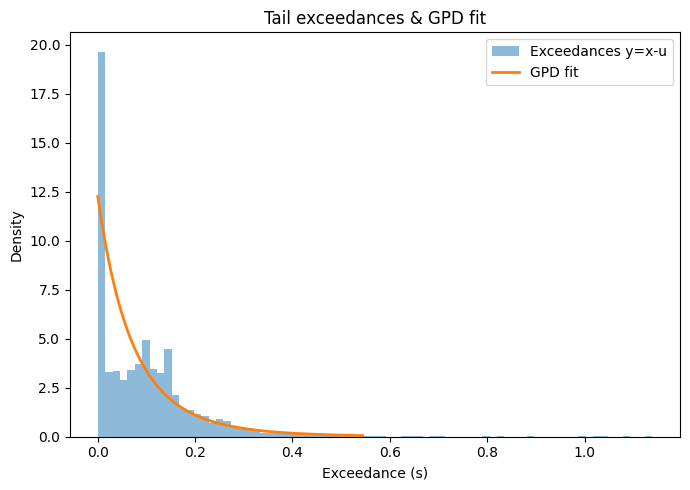

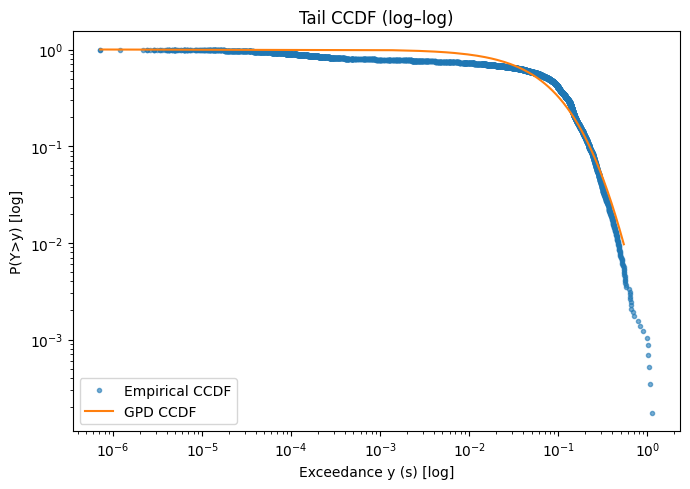

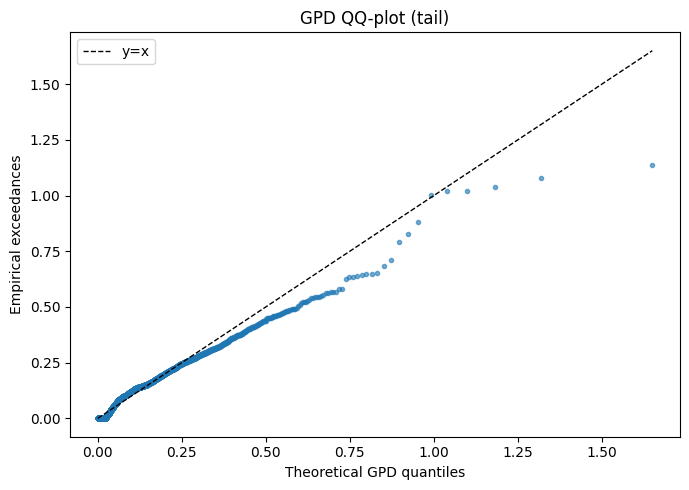

In [33]:
# Histogram + PDFs on exceedances
ys = np.sort(y)
bins = max(30, int(np.sqrt(len(ys))))
plt.hist(ys, bins=bins, density=True, alpha=0.5, label="Exceedances y=x-u")
grid = np.linspace(0, np.quantile(ys, 0.995), 400)
plt.plot(grid, st.genpareto.pdf(grid, xi, loc=0, scale=beta), lw=2, label="GPD fit")
plt.xlabel("Exceedance (s)"); plt.ylabel("Density")
plt.title("Tail exceedances & GPD fit")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "tail_pdf.png"))
plt.show()

# CCDF (survival) on log–log
emp_sf = 1.0 - (np.arange(1, len(ys)+1) / (len(ys)+1.0))
def gpd_sf(t):
    base = np.maximum(1 + xi*t/beta, 1e-12)
    return np.exp(-t/beta) if abs(xi)<1e-10 else base**(-1/xi)

grid2 = np.linspace(ys.min(), np.quantile(ys, 0.995), 400)
plt.loglog(ys+1e-12, emp_sf, 'o', ms=3, alpha=0.6, label="Empirical CCDF")
plt.loglog(grid2+1e-12, [gpd_sf(t) for t in grid2], label="GPD CCDF")
plt.xlabel("Exceedance y (s) [log]"); plt.ylabel("P(Y>y) [log]")
plt.title("Tail CCDF (log–log)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "tail_ccdf.png"))
plt.show()

# GPD QQ plot
probs = (np.arange(1, len(ys)+1) - 0.5) / len(ys)
theo = st.genpareto.ppf(probs, xi, loc=0, scale=beta)
plt.plot(theo, ys, 'o', ms=3, alpha=0.6)
mmin, mmax = min(theo.min(), ys.min()), max(theo.max(), ys.max())
plt.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label="y=x")
plt.xlabel("Theoretical GPD quantiles"); plt.ylabel("Empirical exceedances")
plt.title("GPD QQ-plot (tail)"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "gpd_qq.png"))
plt.show()


In [34]:
verdict = {
    "n_samples": int(len(x)),
    "whole_best_family": best_name,
    "whole_params": list(best_params),
    "threshold_u_seconds": float(u),
    "prop_le_u": float(p_u),
    "gpd_xi": float(xi),
    "gpd_beta": float(beta),
    "tail_type": "Frechet/heavy" if xi>0 else ("Gumbel/exponential" if abs(xi)<1e-10 else "Weibull/bounded"),
    "p95_ms": float(gpd_quantile_global(0.95, u, xi, beta, p_u)*1000),
    "p99_ms": float(gpd_quantile_global(0.99, u, xi, beta, p_u)*1000),
    "p999_ms": float(gpd_quantile_global(0.999, u, xi, beta, p_u)*1000),
    "P_gt_500ms": float(prob_exceed_global(0.5, u, xi, beta, p_u)),
    "P_gt_1000ms": float(prob_exceed_global(1.0, u, xi, beta, p_u)),
}

print(json.dumps(verdict, indent=2))
with open(os.path.join(OUTDIR, "summary.json"), "w") as f:
    json.dump(verdict, f, indent=2)

print(f"[DONE] Plots + summary in: {OUTDIR}")


{
  "n_samples": 57500,
  "whole_best_family": "lognorm",
  "whole_params": [
    0.755131,
    0.0,
    0.012463
  ],
  "threshold_u_seconds": 0.0164909362792968,
  "prop_le_u": 0.9000173913043479,
  "gpd_xi": 0.1483872599632578,
  "gpd_beta": 0.08152373193202742,
  "tail_type": "Frechet/heavy",
  "p95_ms": 75.99145450018743,
  "p99_ms": 240.2419931477404,
  "p999_ms": 555.1472246822282,
  "P_gt_500ms": 0.0014198161903642924,
  "P_gt_1000ms": 9.926109319071351e-05
}
[DONE] Plots + summary in: evt_output
